In [1]:
#download the correlation results for the RNA-ATAC correlation analysis across all windows
import pandas as pd
cor_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_correlation_ct_time_results.csv")
cor_res_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj
0,10kb,rpl24,1-2372-3057,-0.311027,9.118685e-06,5.040068,6.425554e-05,4.192089
1,10kb,rpl24,1-3427-4032,-0.405068,3.884092e-09,8.410711,5.260168e-08,7.279000
2,10kb,rpl24,1-4469-7268,-0.167507,1.894020e-02,1.722615,5.040299e-02,1.297544
3,10kb,rpl24,1-9541-9969,-0.148999,3.713353e-02,1.430234,8.728105e-02,1.059080
4,10kb,rpl24,1-11007-12962,-0.304377,1.441907e-05,4.841063,9.717434e-05,4.012448


In [ ]:
#classify every peak–gene pair into one of three categories and count how many pairs fall into each category per window and gene
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# classify every peak–gene pair into one of three categories 
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# Make window categorical and ordered
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

agg_cor_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_df.head()


/tmp/ipykernel_1187934/1743582331.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene", "category"])


,window,gene,category,count
0,10kb,a1cf,non-significant,2
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,9
3,10kb,a2ml,non-significant,11
4,10kb,a2ml,sig. negative,0


# Different here:
"Dedublication" of gene-peak pairs, meaning we keep only the first occurrence of each pair across all windows
- ordering by window size, we keep the pair with the smallest window size

In [2]:
# classify every peak–gene pair into one of three categories 
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# Make window categorical and ordered
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
cor_res_df = cor_res_df.sort_values("window", ascending=True)
cor_res_df

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# "Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    cor_res_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

# Sort by window 
pair_summary = pair_summary.sort_values("window", ascending=True)
pair_summary

# Sanity check - how many times each gene-peak pair appears in the summary
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
pair_counts['count'].value_counts()

# Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = pair_summary.groupby(['window', 'gene', 'category']).size().reset_index(name="count")
summary_counts


/tmp/ipykernel_1187934/1867345724.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = pair_summary.groupby(['window', 'gene', 'category']).size().reset_index(name="count")


,window,gene,category,count
0,10kb,a1cf,non-significant,2
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,9
3,10kb,a2ml,non-significant,11
4,10kb,a2ml,sig. negative,0
...,...,...,...,...
229987,100kb,zzef1,sig. negative,0
229988,100kb,zzef1,sig. positive,16
229989,100kb,zzz3,non-significant,36
229990,100kb,zzz3,sig. negative,1


/tmp/ipykernel_1187934/2213669439.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


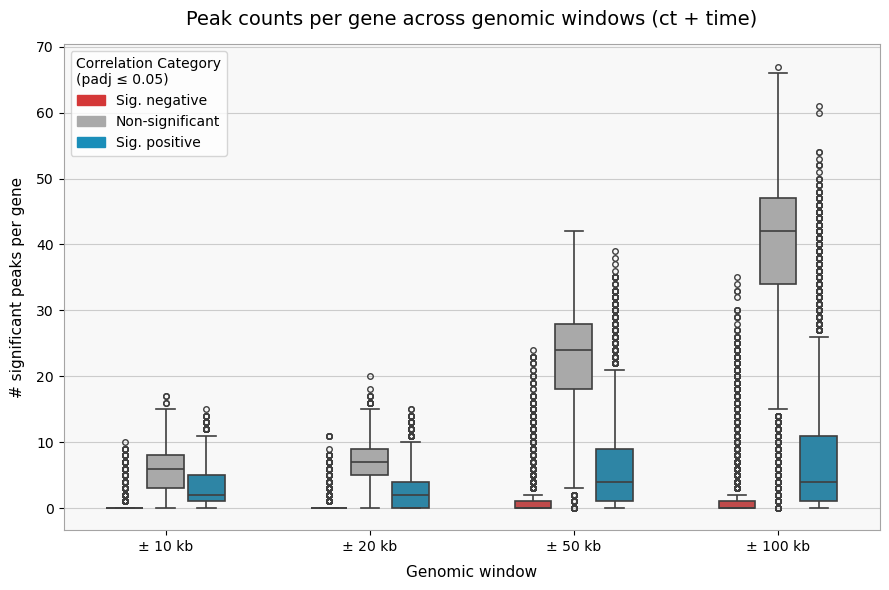

In [3]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "± 10 kb",
    "20kb":  "± 20 kb",
    "50kb":  "± 50 kb",
    "100kb": "± 100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct + time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Correlation Category\n(padj ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/first_pair_count_cor_ct_time.png", dpi=300)
plt.show()

/tmp/ipykernel_1187934/880293227.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


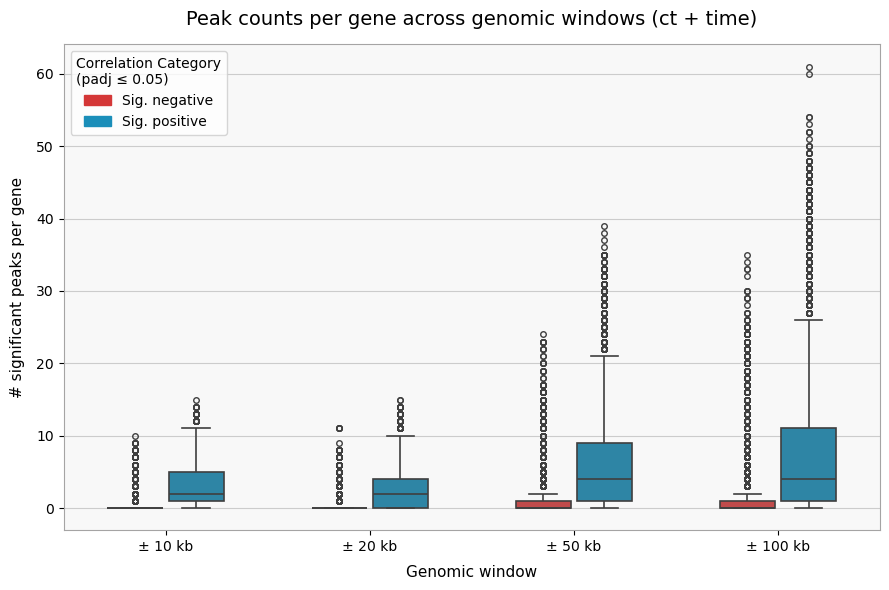

In [4]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "± 10 kb",
    "20kb":  "± 20 kb",
    "50kb":  "± 50 kb",
    "100kb": "± 100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct + time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Correlation Category\n(padj ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/first_pair_count_cor_ct_time2.png", dpi=300)
plt.show()